In [1]:

import tensorflow as tf
import numpy as np
from tensorflow.python.framework import ops
from sklearn import preprocessing
from sklearn.linear_model import enet_path
from scipy.sparse import spdiags,eye,csc_matrix, diags
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K
from tensorflow.keras.layers import Layer
import copy
import csv

In [2]:
def SSPmodel(X):
    # X：processed training data [:,2,N,1],N represents the length of spectra
    # inputA: spectra from database
    # inputB：spectra of unknown


    inputs = tf.keras.layers.Input((2,None,1))

    inputA = inputs[:,0,:]
    inputB = inputs[:,1,:]


    convA1 = tf.keras.layers.Conv1D(64, kernel_size=(7), strides=(1),padding = 'same', kernel_initializer = 'he_normal')(inputA)
    convA1 = tf.keras.layers.BatchNormalization()(convA1)
    convA1 = tf.keras.layers.Activation('relu')(convA1)
    poolA1 = tf.keras.layers.MaxPooling1D(3)(convA1)


    convB1 = tf.keras.layers.Conv1D(32, kernel_size=(7), strides=(1),padding = 'same', kernel_initializer = 'he_normal')(inputB)
    convB1 = tf.keras.layers.BatchNormalization()(convB1)
    convB1 = tf.keras.layers.Activation('relu')(convB1)
    poolB1 = tf.keras.layers.MaxPooling1D(3)(convB1)

    con = tf.keras.layers.concatenate([poolA1,poolB1],2)
    con = tf.expand_dims(con, -1)

    conv1 = tf.keras.layers.Conv2D(32, kernel_size=(7,7), strides=(2,2),padding = 'same', kernel_initializer = 'he_normal')(con)
    conv1 = tf.keras.layers.BatchNormalization()(conv1)
    conv1 = tf.keras.layers.Activation('relu')(conv1)

    spp = SpatialPyramidPooling([1, 2, 3, 4])(conv1)

    full1 = tf.keras.layers.Dense(1024, activation='relu')(spp)
    drop1 = tf.keras.layers.Dropout(0.5)(full1)


    outputs = tf.keras.layers.Dense(2, activation='sigmoid')(drop1)#sigmoid
    model = tf.keras.models.Model(inputs,outputs)
    return model

def WhittakerSmooth(x, lamb, w):
    m=w.shape[0]
    W=spdiags(w,0,m,m)
    D=eye(m-1,m,1)-eye(m-1,m)
    return spsolve((W+lamb*D.transpose()*D),w*x)

def airPLS(x, lamb=10, itermax=10):
    m=x.shape[0]
    w=np.ones(m)
    for i in range(itermax):
        z=WhittakerSmooth(x,lamb,w)
        d=x-z
        if sum(abs(d[d<0]))<0.001*sum(abs(x)):
            break;
        w[d<0]=np.exp(i*d[d<0]/sum(d[d<0]))
        w[d>=0]=0
    return z

def airPLS_MAT(X, lamb=10, itermax=10):
    B=X.copy()
    for i in range(X.shape[0]):
        B[i,]=airPLS(X[i,],lamb,itermax)
    return X-B

def WhittakerSmooth_MAT(X, lamb=1):
    C=X.copy()
    w=np.ones(X.shape[1])
    for i in range(X.shape[0]):
        C[i,]=WhittakerSmooth(X[i,:], lamb, w)

    return C

In [3]:
class SpatialPyramidPooling(Layer):

    def __init__(self, pool_list, **kwargs):

        self.dim_ordering = K.image_data_format()
        assert self.dim_ordering in {'channels_last', 'channels_first'}, 'dim_ordering must be in {tf, th}'

        self.pool_list = pool_list

        self.num_outputs_per_channel = sum([i * i for i in pool_list])

        super(SpatialPyramidPooling, self).__init__(**kwargs)

    def build(self, input_shape):
            self.nb_channels = input_shape[3]


    def get_output_shape_for(self, input_shape):
        return (input_shape[0], self.nb_channels * self.num_outputs_per_channel)

    def get_config(self):
        config = {'pool_list': self.pool_list}
        base_config = super(SpatialPyramidPooling, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

    def call(self, x, mask=None):

        input_shape = K.shape(x)


        num_rows = input_shape[1]
        num_cols = input_shape[2]

        row_length = [K.cast(num_rows, 'float32') / i for i in self.pool_list]
        col_length = [K.cast(num_cols, 'float32') / i for i in self.pool_list]

        outputs = []


        for pool_num, num_pool_regions in enumerate(self.pool_list):

            for ix in range(num_pool_regions):
                for iy in range(num_pool_regions):
                    x1 = ix * col_length[pool_num]
                    x2 = ix * col_length[pool_num] + col_length[pool_num]
                    y1 = iy * row_length[pool_num]
                    y2 = iy * row_length[pool_num] + row_length[pool_num]

                    x1 = K.cast(K.round(x1), 'int32')
                    x2 = K.cast(K.round(x2), 'int32')
                    y1 = K.cast(K.round(y1), 'int32')
                    y2 = K.cast(K.round(y2), 'int32')

                    new_shape = [input_shape[0], y2 - y1,
                                 x2 - x1, input_shape[3]]
                    x_crop = x[:, y1:y2, x1:x2, :]
                    xm = K.reshape(x_crop, new_shape)
                    pooled_val = K.max(xm, axis=(1, 2))
                    outputs.append(pooled_val)

        if self.dim_ordering == 'channels_first':
            outputs = K.concatenate(outputs)
        elif self.dim_ordering == 'channels_last':
            outputs = K.concatenate(outputs,axis = 0)
            outputs = K.reshape(outputs,(self.num_outputs_per_channel,input_shape[0], self.nb_channels))
            outputs = K.permute_dimensions(outputs,(1,0,2))
            outputs = K.reshape(outputs,(input_shape[0], self.num_outputs_per_channel * self.nb_channels))
        return outputs

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf

# ——— import your actual functions here ———
# from your_utils import WhittakerSmooth_MAT, airPLS_MAT
def snv(X):
    """Apply Standard Normal Variate (SNV) to each row (spectrum) in X."""
    return (X - np.mean(X, axis=1, keepdims=True)) / np.std(X, axis=1, keepdims=True)

def normalize_rows(X):
    """
    Zero‐shift each row, then divide by its max (safely).
    X: 2D array shape (n_rows, n_points)
    """
    X = X - X.min(axis=1, keepdims=True)
    maxv = X.max(axis=1, keepdims=True)
    maxv[maxv == 0] = 1.0
    return X / maxv

def build_deepraman_dataset(pure_csv, mix_csv, smooth=True):
    # 1) Load CSVs
    df_pure = pd.read_csv(pure_csv, index_col=0)  # rows=shift, cols=compound
    df_mix  = pd.read_csv(mix_csv)                # cols = concs + shift columns

    compounds = df_pure.columns.tolist()
    mix_cols  = df_mix.columns.tolist()

    # 2) Identify spectral columns (anything not matching a compound name)
    spec_cols = [c for c in mix_cols
                 if not any(comp.lower() in c.lower() for comp in compounds)]

    # 3) Find exactly one concentration column per compound
    conc_cols = []
    for comp in compounds:
        matches = [c for c in mix_cols if comp.lower() in c.lower()]
        if len(matches) != 1:
            raise KeyError(f"Expected 1 column for '{comp}', found: {matches}")
        conc_cols.append(matches[0])

    # 4) Extract into NumPy
    # pure_sp: (n_compounds, n_points_pure)
    pure_sp = df_pure.values.T.astype('float32')
    # mix_sp:  (n_samples,   n_points_mix)
    mix_sp  = df_mix[spec_cols].values.astype('float32')
    # conc_mat: (n_samples, n_compounds)
    conc_mat = df_mix[conc_cols].values.astype('float32')

    # 5) Baseline removal if desired
    if smooth:
        pure_sp = WhittakerSmooth_MAT(pure_sp, lamb=1)
        pure_sp = airPLS_MAT(pure_sp, lamb=10, itermax=10)
        mix_sp  = WhittakerSmooth_MAT(mix_sp, lamb=1)
        mix_sp  = airPLS_MAT(mix_sp, lamb=10, itermax=10)

    # 6) Normalize rows
    pure_corr = snv(pure_sp)
    mix_corr  = snv(mix_sp)

    # 7) Trim to common length
    np_pure = pure_corr.shape[1]
    np_mix  = mix_corr.shape[1]
    if np_pure != np_mix:
        n_points = min(np_pure, np_mix)
        pure_corr = pure_corr[:, :n_points]
        mix_corr  = mix_corr[:, :n_points]
    else:
        n_points = np_pure

    # 8) Build pairwise (ref, mix) dataset
    n_samples   = mix_corr.shape[0]
    n_compounds = pure_corr.shape[0]
    N = n_samples * n_compounds

    X = np.zeros((N, 2, n_points, 1), dtype='float32')
    Y = np.zeros((N, 1),           dtype='int32')

    idx = 0
    for i in range(n_samples):
        for j in range(n_compounds):
            X[idx, 0, :, 0] = pure_corr[j]
            X[idx, 1, :, 0] = mix_corr[i]
            Y[idx, 0]       = 1 if conc_mat[i, j] > 0 else 0
            idx += 1

    # 9) One-hot labels for binary_crossentropy
    Y = tf.keras.utils.to_categorical(Y, num_classes=2)

    return X, Y, compounds, spec_cols

In [5]:

    pure_csv = r'C:\Users\MathiasCharconnet\PycharmProjects\DeepRaman\Pure_compounds.csv'
    mix_csv  = (r'C:\Users\MathiasCharconnet\PycharmProjects\DeepRaman\test_deep_learning.csv')

    # build the dataset
    X, Y, compounds, shifts = build_deepraman_dataset(pure_csv, mix_csv, smooth=False)

    # optionally split into train/validation
    from sklearn.model_selection import train_test_split
    X_train, X_val, Y_train, Y_val = train_test_split(
        X, Y, test_size=0.1, random_state=42, stratify=Y.argmax(axis=1)
    )

    print("X shape:", X.shape)           # (n_samples*n_compounds, 2, n_points, 1)
    print("Y shape:", Y.shape)           # (n_samples*n_compounds, 2)
    print("Train/Val sizes:", X_train.shape[0], X_val.shape[0])

X shape: (3000, 2, 2000, 1)
Y shape: (3000, 2)
Train/Val sizes: 2700 300


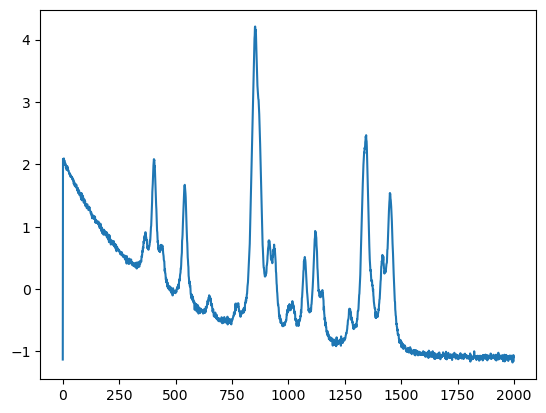

In [6]:
plt.plot(X[1][1])


In [ ]:

    # 3) Instantiate and compile the SPP model
    model = SSPmodel(X_train)  # input shape inferred from X_train
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model.summary()

    # 4) Train
    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        batch_size=200,
        epochs=50,
        verbose=1
    )

    # 5) Plot training & validation metrics
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(history.history['accuracy'], label='train acc')
    ax1.plot(history.history['val_accuracy'], label='val acc')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(history.history['loss'], '--', label='train loss')
    ax2.plot(history.history['val_loss'], '--', label='val loss')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='lower right')

    plt.title('SPP Model Training')
    plt.show()



Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Index'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Index'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Model: "functional_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 2, None, 1)] 0                                            
_________________________________________________________________________________